# Module 6 / Class 3 - CNN on MNIST

This notebook builds a dense baseline, a CNN, and the required CNN
with Dropout. The Dropout model uses `Dropout(0.25)` after each
MaxPooling layer and `Dropout(0.5)` before the final Dense output.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from IPython.display import Markdown, display

np.random.seed(42)
tf.keras.utils.set_random_seed(42)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Load and Prepare MNIST

The dense model uses `(28, 28)` images. The CNN models use
`(28, 28, 1)` because convolution layers expect a channel dimension.

In [2]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

x_train = x_train_full[:7000].astype("float32") / 255.0
y_train = y_train_full[:7000]
x_valid = x_train_full[7000:8500].astype("float32") / 255.0
y_valid = y_train_full[7000:8500]
x_test = x_test_full[:2000].astype("float32") / 255.0
y_test = y_test_full[:2000]

x_train_cnn = x_train[..., np.newaxis]
x_valid_cnn = x_valid[..., np.newaxis]
x_test_cnn = x_test[..., np.newaxis]

print("dense input:", x_train.shape)
print("cnn input:", x_train_cnn.shape)

dense input: (7000, 28, 28)
cnn input: (7000, 28, 28, 1)


## 2. Build Models

The Dropout CNN has the same convolution structure as the normal CNN,
with Dropout added only in the required places.

In [3]:
def build_dense_model():
    return keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

def build_cnn_model():
    return keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(16, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

def build_cnn_dropout_model():
    return keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(16, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),
    ])

In [4]:
def train_model(model, train_x, valid_x, test_x, epochs=5):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    history = model.fit(
        train_x,
        y_train,
        validation_data=(valid_x, y_valid),
        epochs=epochs,
        batch_size=128,
        verbose=0,
    )
    test_loss, test_accuracy = model.evaluate(test_x, y_test, verbose=0)
    return history.history, test_accuracy

model_specs = [
    ("Dense baseline", build_dense_model(), x_train, x_valid, x_test),
    ("CNN", build_cnn_model(), x_train_cnn, x_valid_cnn, x_test_cnn),
    ("CNN + Dropout", build_cnn_dropout_model(), x_train_cnn, x_valid_cnn, x_test_cnn),
]

histories = {}
test_scores = {}

for model_name, model, train_x, valid_x, test_x in model_specs:
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)
    history, test_accuracy = train_model(model, train_x, valid_x, test_x, epochs=5)
    histories[model_name] = history
    test_scores[model_name] = test_accuracy

comparison_df = pd.DataFrame([
    {"model": name, "test_accuracy": accuracy}
    for name, accuracy in test_scores.items()
]).sort_values("test_accuracy", ascending=False)
comparison_df

,model,test_accuracy
1,CNN,0.9530
2,CNN + Dropout,0.9320
0,Dense baseline,0.8855


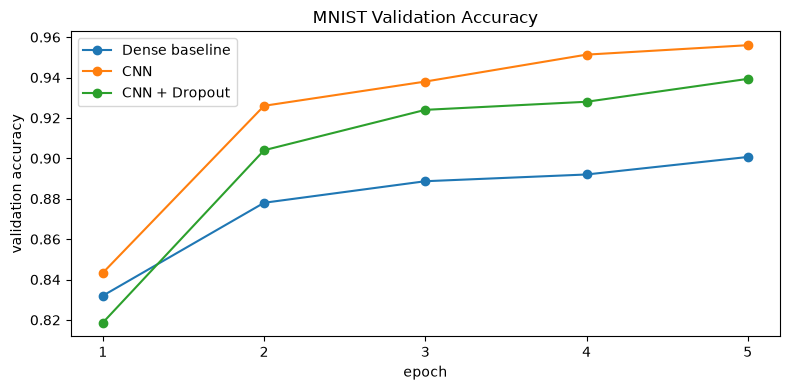

In [5]:
plt.figure(figsize=(8, 4))
for model_name, history in histories.items():
    plt.plot(history["val_accuracy"], marker="o", label=model_name)

plt.title("MNIST Validation Accuracy")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.xticks(range(5), ["1", "2", "3", "4", "5"])
plt.legend()
plt.tight_layout()
plt.show()

## 3. Dropout Comparison - Completed

The next cell compares the original CNN with the Dropout CNN using
the test accuracies from this run.

In [6]:
cnn_acc = test_scores["CNN"]
dropout_acc = test_scores["CNN + Dropout"]

if dropout_acc > cnn_acc:
    helped_text = "Dropout helped slightly in this run because the Dropout CNN had higher test accuracy."
else:
    helped_text = "Dropout did not improve test accuracy in this short run. MNIST is simple, so regularization may not help unless the model is overfitting."

answer = f'''
- **CNN test accuracy:** `{cnn_acc:.4f}`
- **CNN + Dropout test accuracy:** `{dropout_acc:.4f}`
- **Did Dropout help?** {helped_text}
'''

display(Markdown(answer))


- **CNN test accuracy:** `0.9530`
- **CNN + Dropout test accuracy:** `0.9320`
- **Did Dropout help?** Dropout did not improve test accuracy in this short run. MNIST is simple, so regularization may not help unless the model is overfitting.
